Evaluation et interpretation

├── Cellule 1 — Chargement du pipeline

├── Cellule 2 — Étape 6a : Stabilité Bootstrap 

├── Cellule 3 — Étape 6b : Individus ambigus 

├── Cellule 4 — Étape 6c : Pouvoir discriminant 

├── Cellule 5 — Étape 6d : Biais et limites 

└── Cellule 6 — Étape 6e : Script de prédiction 

In [2]:
# ══════════════════════════════════════════════════════════════════
# ÉTAPE 06 — ÉVALUATION ET INTERPRÉTATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})

# ── 1. Chargement du pipeline sauvegardé ─────────────────────────
PIPELINE_DIR = r"C:\\Users\\DELL\Desktop\Formation Data-science_FRST_FDS\Projet_Capstone\Segmentation_Inclusion_Financiere_Groupe5\Scripts\Modelisation IA\pipeline_segmentation"
scaler    = joblib.load(f"{PIPELINE_DIR}/scaler.pkl")
pca_afdm  = joblib.load(f"{PIPELINE_DIR}/pca_afdm.pkl")
kmeans    = joblib.load(f"{PIPELINE_DIR}/kmeans_final.pkl")
encodeurs = joblib.load(f"{PIPELINE_DIR}/encodeurs.pkl")

# Récupération des paramètres
ordre_education     = encodeurs["ordre_education"]
ordre_planification = encodeurs["ordre_planification"]
ordre_inclusion     = encodeurs["ordre_inclusion"]
VARS_BIN            = encodeurs["VARS_BIN"]
VARS_ORD            = encodeurs["VARS_ORD"]
COLS_MODEL          = encodeurs["COLS_MODEL"]
cols_sec            = encodeurs["cols_sec"]
K_FINAL             = encodeurs["K_FINAL"]
noms_clusters       = encodeurs["noms_clusters"]

print(" Pipeline chargé depuis :", PIPELINE_DIR)
print(f"   Scaler    : {scaler.__class__.__name__}")
print(f"   AFDM      : PCA {pca_afdm.n_components_} composantes")
print(f"   K-means   : k={kmeans.n_clusters}")
print()

# ── 2. Chargement du dataset avec clusters ────────────────────────
df_final = pd.read_csv(
    f"{PIPELINE_DIR}/dataset_avec_clusters.csv",
    encoding="utf-8-sig"
)
print(f"Dataset chargé : {df_final.shape[0]:,} individus × "
      f"{df_final.shape[1]} variables")

# Reconstruction de X et X_pca
FILE ="C:\\Users\\DELL\\Desktop\\Formation Data-science_FRST_FDS\\Projet_Capstone\\Segmentation_Inclusion_Financiere_Groupe5\\Donnees\\Donnees_Nettoyees\\FinScope_Haiti_2018_Données nettoyées.xlsx"
df_brut = pd.read_excel(FILE, sheet_name="Données_Nettoyées")
df = df_brut[df_brut["Jamais_Eu_Credit_Formel"] == "Oui"].copy()
df.reset_index(drop=True, inplace=True)

df_enc = df.copy()
for var in VARS_BIN:
    df_enc[var] = (df_enc[var] == "Oui").astype(int)
df_enc["Niveau_Education"] = df_enc["Niveau_Education"]\
                                     .map(ordre_education)
df_enc["Planification_Financiere"] = df_enc["Planification_Financiere"]\
                                             .map(ordre_planification)
df_enc["Niveau_Inclusion_Financiere"] = df_enc["Niveau_Inclusion_Financiere"]\
                                               .map(ordre_inclusion)
df_enc["Revenu_log"] = np.log1p(df_enc["Revenu_Mensuel_HTG"])
df_enc = pd.get_dummies(df_enc, columns=["Secteur_Activite"],
                        prefix="Sec", drop_first=False)

X        = df_enc[COLS_MODEL].copy()
X_scaled = scaler.transform(X)
X_pca    = pca_afdm.transform(X_scaled)
labels_km = df_final["Cluster"].values

from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score,
                              davies_bouldin_score,
                              adjusted_rand_score)

print(f"\nVérification labels :")
print(f"  Silhouette : {silhouette_score(X_pca, labels_km):.4f}")


 Pipeline chargé depuis : C:\\Users\\DELL\Desktop\Formation Data-science_FRST_FDS\Projet_Capstone\Segmentation_Inclusion_Financiere_Groupe5\Scripts\Modelisation IA\pipeline_segmentation
   Scaler    : StandardScaler
   AFDM      : PCA 12 composantes
   K-means   : k=6

Dataset chargé : 4,016 individus × 39 variables

Vérification labels :
  Silhouette : 0.2683


### ÉVALUATION CONSOLIDÉE ET STABILITÉ

════════════════════════════════════════════════════════════
 ÉVALUATION CONSOLIDÉE ET STABILITÉ
════════════════════════════════════════════════════════════

Métriques du modèle final (K-means, k=6) :
  Silhouette          : 0.2683
  Calinski-Harabasz   : 638.12
  Davies-Bouldin      : 1.4631
  Inertie             : 32306.46

Décomposition de la variance :
  Inertie totale : 58011.44
  Inertie intra  : 32306.46 (55.7%)
  Inertie inter  : 25704.98 (44.3%)
  → 44.3% de la variance expliquée par les clusters

Test de stabilité Bootstrap (50 runs)...
  ARI moyen  : 1.0000
  Écart-type : 0.0000
  ARI minimum: 1.0000
   Clustering très stable (ARI > 0.90)



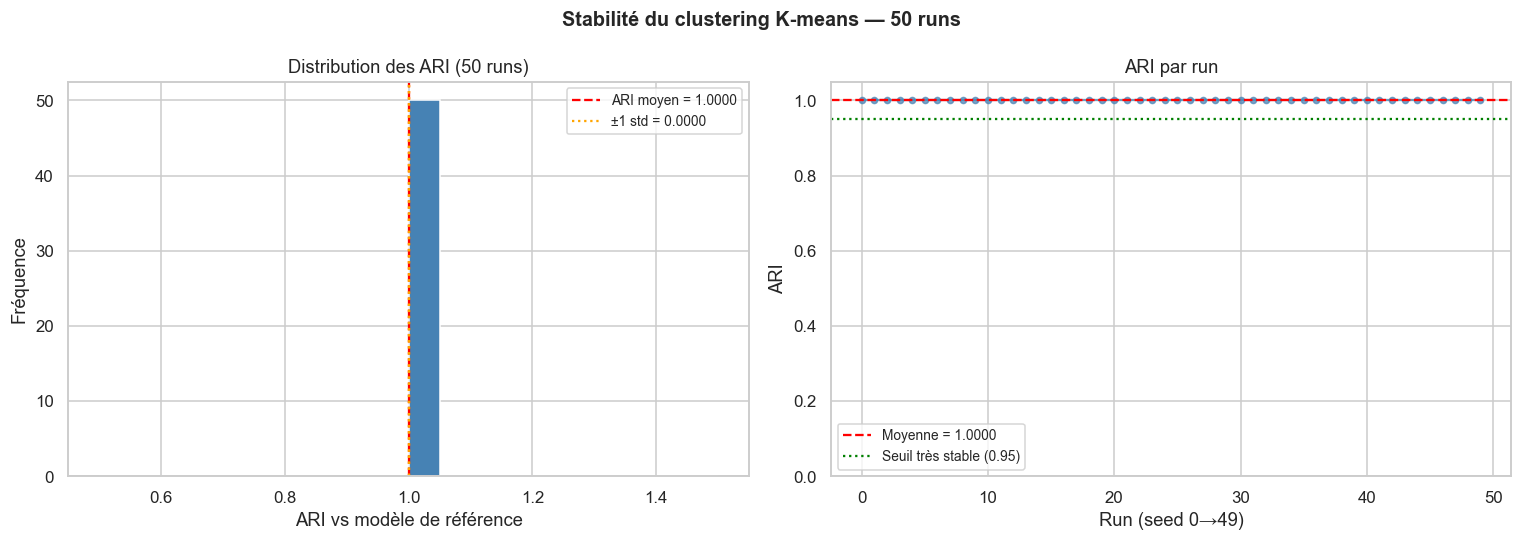

Tableau comparatif final — toutes méthodes :
          Méthode  Silhouette Calinski-Harabasz Davies-Bouldin ARI vs K-means  Clusters Retenu
          K-means      0.2683            638.12         1.4631      Référence         6    OUI
         CAH Ward      0.2136            512.91         1.7639         0.7316         6    Non
   K-médoïdes PAM      0.1421            347.43         2.0552         0.5525         6    Non
Mixte CAH+K-means      0.2683            638.12         1.4631            1.0         6    Non
 DBSCAN (eps=2.0)      0.2466                 —              —              —        20    Non



In [3]:
# ══════════════════════════════════════════════════════════════════
# ÉTAPE 6a — ÉVALUATION CONSOLIDÉE ET STABILITÉ
# ══════════════════════════════════════════════════════════════════

from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

print("═"*60)
print(" ÉVALUATION CONSOLIDÉE ET STABILITÉ")
print("═"*60)

# ── 1. Métriques du modèle final ──────────────────────────────────
sil_final = silhouette_score(X_pca, labels_km)
ch_final  = calinski_harabasz_score(X_pca, labels_km)
db_final  = davies_bouldin_score(X_pca, labels_km)

print(f"\nMétriques du modèle final (K-means, k={K_FINAL}) :")
print(f"  Silhouette          : {sil_final:.4f}")
print(f"  Calinski-Harabasz   : {ch_final:.2f}")
print(f"  Davies-Bouldin      : {db_final:.4f}")
print(f"  Inertie             : {kmeans.inertia_:.2f}\n")

# ── 2. Décomposition inertie inter / intra ────────────────────────
inertie_totale = np.sum((X_pca - X_pca.mean(axis=0))**2)
inertie_intra  = kmeans.inertia_
inertie_inter  = inertie_totale - inertie_intra
ratio          = inertie_inter / inertie_totale * 100

print(f"Décomposition de la variance :")
print(f"  Inertie totale : {inertie_totale:.2f}")
print(f"  Inertie intra  : {inertie_intra:.2f} ({100-ratio:.1f}%)")
print(f"  Inertie inter  : {inertie_inter:.2f} ({ratio:.1f}%)")
print(f"  → {ratio:.1f}% de la variance expliquée par les clusters\n")

# ── 3. Stabilité Bootstrap (50 runs) ─────────────────────────────
print("Test de stabilité Bootstrap (50 runs)...")
N_RUNS     = 50
ari_scores = []

for seed in range(N_RUNS):
    km_test = KMeans(n_clusters=K_FINAL, init="k-means++",
                     n_init=10, random_state=seed)
    labels_test = km_test.fit_predict(X_pca)
    ari_scores.append(adjusted_rand_score(labels_km, labels_test))

ari_mean = np.mean(ari_scores)
ari_std  = np.std(ari_scores)
ari_min  = np.min(ari_scores)

print(f"  ARI moyen  : {ari_mean:.4f}")
print(f"  Écart-type : {ari_std:.4f}")
print(f"  ARI minimum: {ari_min:.4f}")
if ari_mean > 0.90:
    print("   Clustering très stable (ARI > 0.90)")
elif ari_mean > 0.80:
    print("   Clustering stable (ARI > 0.80)")
else:
    print("   Clustering modérément stable")
print()

# Graphique 1 — Stabilité Bootstrap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stabilité du clustering K-means — 50 runs",
             fontweight="bold", fontsize=13)

axes[0].hist(ari_scores, bins=20, color="steelblue",
             edgecolor="white")
axes[0].axvline(ari_mean, color="red", linestyle="--",
                label=f"ARI moyen = {ari_mean:.4f}")
axes[0].axvline(ari_mean - ari_std, color="orange",
                linestyle=":", label=f"±1 std = {ari_std:.4f}")
axes[0].axvline(ari_mean + ari_std, color="orange",
                linestyle=":")
axes[0].set_xlabel("ARI vs modèle de référence")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution des ARI (50 runs)")
axes[0].legend(fontsize=9)

axes[1].plot(range(N_RUNS), ari_scores, "o-",
             markersize=4, color="steelblue", alpha=0.7)
axes[1].axhline(ari_mean, color="red", linestyle="--",
                label=f"Moyenne = {ari_mean:.4f}")
axes[1].axhline(0.95, color="green", linestyle=":",
                label="Seuil très stable (0.95)")
axes[1].set_xlabel("Run (seed 0→49)")
axes[1].set_ylabel("ARI")
axes[1].set_title("ARI par run")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ── 4. Tableau comparatif final ───────────────────────────────────
print("Tableau comparatif final — toutes méthodes :")
comparatif = pd.DataFrame({
    "Méthode"          : ["K-means","CAH Ward","K-médoïdes PAM",
                          "Mixte CAH+K-means","DBSCAN (eps=2.0)"],
    "Silhouette"       : [0.2683, 0.2136, 0.1421, 0.2683, 0.2466],
    "Calinski-Harabasz": [638.12, 512.91, 347.43, 638.12, "—"],
    "Davies-Bouldin"   : [1.4631, 1.7639, 2.0552, 1.4631, "—"],
    "ARI vs K-means"   : ["Référence", 0.7316, 0.5525,
                          1.0000, "—"],
    "Clusters"         : [6, 6, 6, 6, 20],
    "Retenu"           : [" OUI","Non","Non","Non","Non"],
})
print(comparatif.to_string(index=False))
print()

### ANALYSE DES INDIVIDUS AMBIGUS

════════════════════════════════════════════════════════════
 ANALYSE DES INDIVIDUS AMBIGUS
════════════════════════════════════════════════════════════

Silhouette moyenne par cluster :
                                    mean     std     min     max  count
Cluster Profil                                                         
0       Agriculteurs vulnérables  0.2730  0.0694  0.0246  0.4038   1116
1       Prestataires de services  0.2775  0.0533  0.1265  0.3717    529
2       Artisans                  0.3156  0.0674  0.1208  0.4446    439
3       Salariés formels          0.3139  0.0736  0.0865  0.4364    307
4       Ménages sans revenus      0.2511  0.0733  0.0441  0.4152    599
5       Commerçants informels     0.2347  0.0495  0.0864  0.3319   1026

Individus ambigus (silhouette < 0) : 0 (0.0%)

Répartition des ambigus par cluster :
Series([], )

Individus frontières (0 ≤ s < 0.10) : 26 (0.6%)
Répartition par cluster :
Profil
Agriculteurs vulnérables    14
Ménages sans revenus     

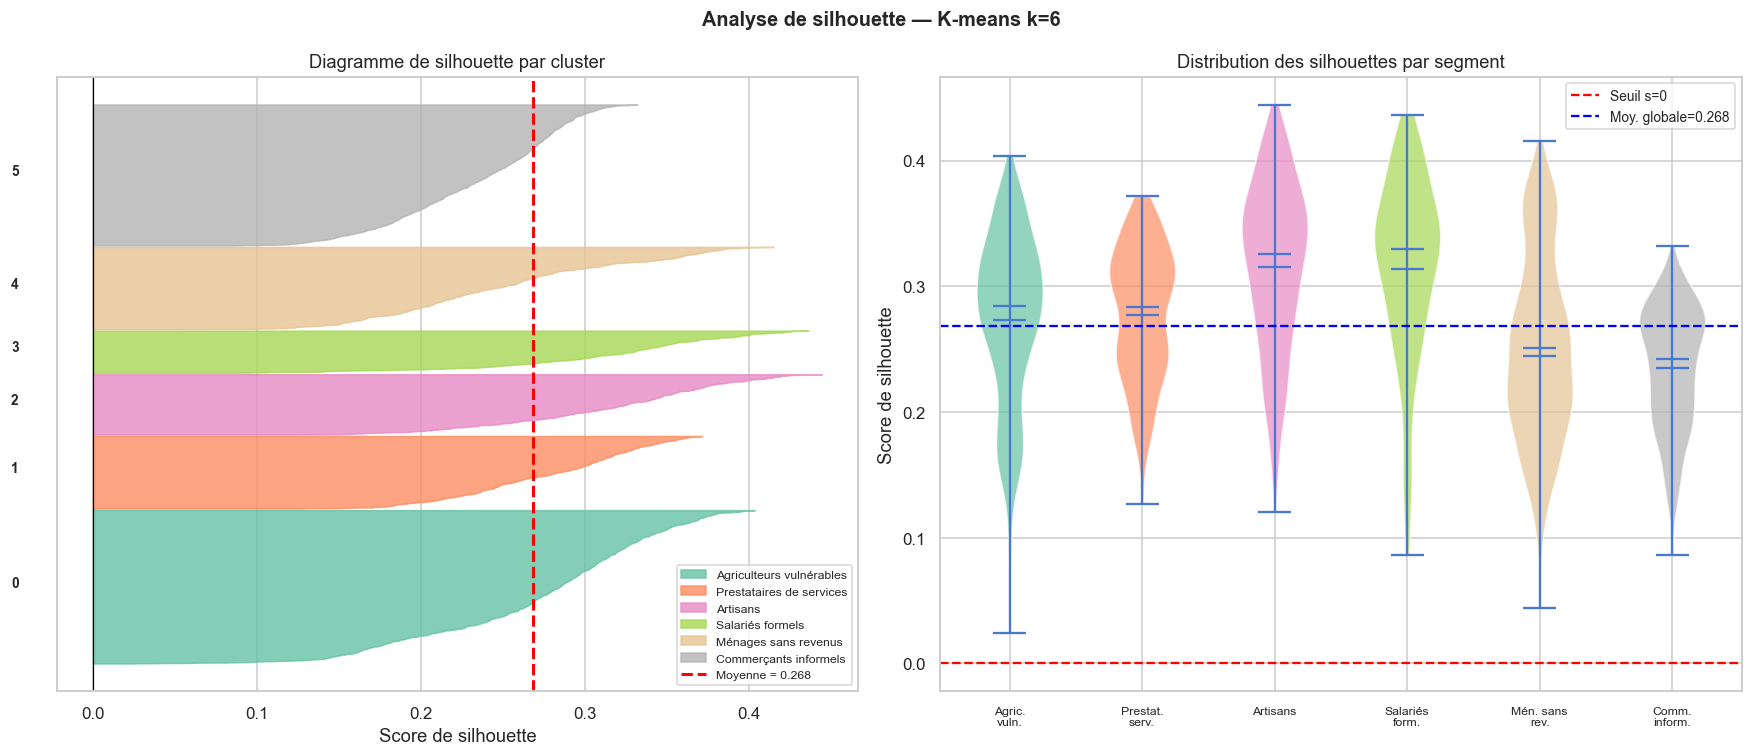

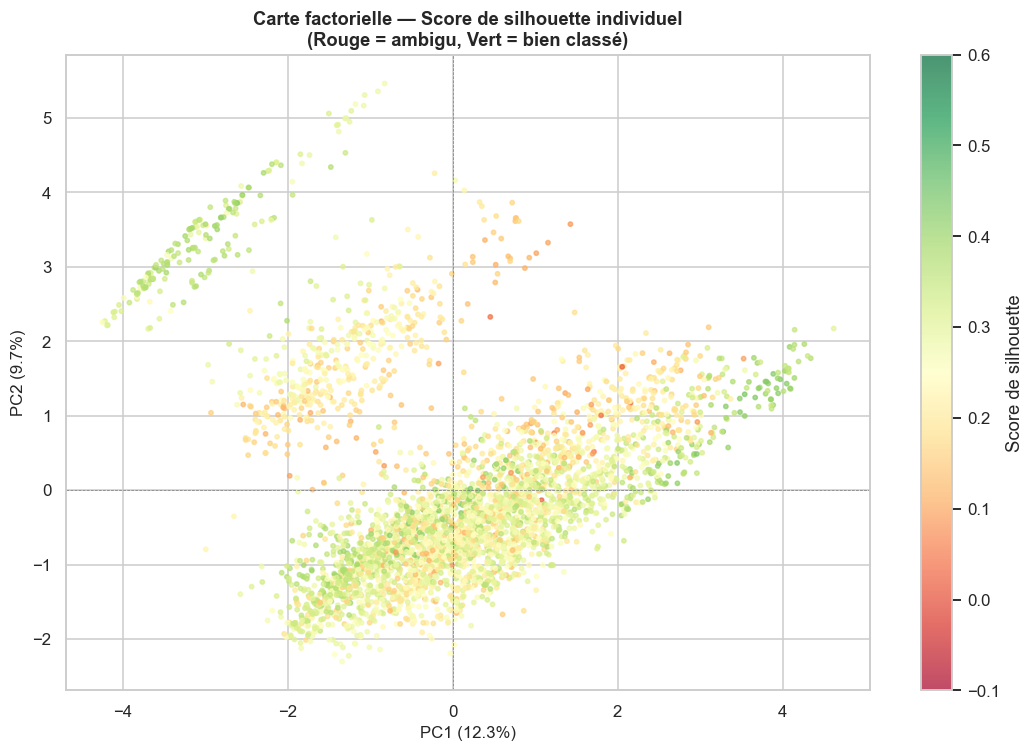

In [4]:
# ══════════════════════════════════════════════════════════════════
# Silhouette individuelle — identifier les cas frontières
# ══════════════════════════════════════════════════════════════════

print("═"*60)
print(" ANALYSE DES INDIVIDUS AMBIGUS")
print("═"*60)

# ── 1. Silhouette individuelle ────────────────────────────────────
sil_vals = silhouette_samples(X_pca, labels_km)
df_sil   = pd.DataFrame({
    "Cluster"    : labels_km,
    "Profil"     : [noms_clusters[c] for c in labels_km],
    "Silhouette" : sil_vals,
})

print("\nSilhouette moyenne par cluster :")
sil_cluster = df_sil.groupby(["Cluster","Profil"])["Silhouette"]\
                    .agg(["mean","std","min","max","count"])\
                    .round(4)
print(sil_cluster.to_string())
print()

# ── 2. Individus ambigus (silhouette < 0) ─────────────────────────
ambigus = df_sil[df_sil["Silhouette"] < 0]
print(f"Individus ambigus (silhouette < 0) : "
      f"{len(ambigus)} ({len(ambigus)/len(df_sil)*100:.1f}%)")
print("\nRépartition des ambigus par cluster :")
print(ambigus["Profil"].value_counts().to_string())
print()

# ── 3. Individus frontières (0 ≤ silhouette < 0.10) ──────────────
frontières = df_sil[(df_sil["Silhouette"] >= 0) &
                    (df_sil["Silhouette"] < 0.10)]
print(f"Individus frontières (0 ≤ s < 0.10) : "
      f"{len(frontières)} ({len(frontières)/len(df_sil)*100:.1f}%)")
print("Répartition par cluster :")
print(frontières["Profil"].value_counts().to_string())
print()

# ── 4. Profil des individus ambigus ──────────────────────────────
VARS_BIN_RAW = encodeurs["VARS_BIN"]
VARS_ORD_RAW = encodeurs["VARS_ORD"]

df_ambigus = df.loc[ambigus.index].copy() \
    if len(ambigus) > 0 else pd.DataFrame()

if len(df_ambigus) > 0:
    df_normal = df.loc[df_sil[df_sil["Silhouette"] >= 0.20].index]

    print("Profil comparatif — Ambigus vs Bien classés (s≥0.20) :")
    vars_comp = ["Revenu_Mensuel_HTG", "Age"]
    comp = pd.DataFrame({
        "Ambigus (s<0)"  : df_ambigus[vars_comp].mean(),
        "Bien classés (s≥0.20)" : df_normal[vars_comp].mean(),
    }).round(1)
    print(comp.to_string())
    print()

# ── 5. Graphique 2 — Diagramme de silhouette final ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Analyse de silhouette — K-means k={K_FINAL}",
             fontweight="bold", fontsize=13)

# Panel gauche — diagramme de silhouette
colors_cl = plt.cm.Set2(np.linspace(0, 1, K_FINAL))
y_lower   = 10

for cl in range(K_FINAL):
    cl_sil = np.sort(sil_vals[labels_km == cl])
    n_cl   = len(cl_sil)
    y_upper = y_lower + n_cl
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0,
                          cl_sil, alpha=0.8,
                          color=colors_cl[cl],
                          label=f"{noms_clusters[cl]}")
    axes[0].text(-0.05, y_lower + 0.5 * n_cl,
                 str(cl), fontweight="bold", fontsize=9)
    y_lower = y_upper + 10

axes[0].axvline(sil_vals.mean(), color="red",
                linestyle="--", linewidth=2,
                label=f"Moyenne = {sil_vals.mean():.3f}")
axes[0].axvline(0, color="black", linestyle="-",
                linewidth=0.8)
axes[0].set_xlabel("Score de silhouette")
axes[0].set_title("Diagramme de silhouette par cluster")
axes[0].set_yticks([])
axes[0].legend(loc="lower right", fontsize=8)

# Panel droit — distribution des scores par cluster (violin)
sil_data  = [sil_vals[labels_km == cl] for cl in range(K_FINAL)]
noms_court = ["Agric.\nvuln.", "Prestat.\nserv.",
               "Artisans", "Salariés\nform.",
               "Mén. sans\nrev.", "Comm.\ninform."]
parts = axes[1].violinplot(sil_data, positions=range(K_FINAL),
                           showmeans=True, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors_cl[i])
    pc.set_alpha(0.7)
axes[1].axhline(0, color="red", linestyle="--",
                linewidth=1.5, label="Seuil s=0")
axes[1].axhline(sil_vals.mean(), color="blue",
                linestyle="--", linewidth=1.5,
                label=f"Moy. globale={sil_vals.mean():.3f}")
axes[1].set_xticks(range(K_FINAL))
axes[1].set_xticklabels(noms_court, fontsize=8)
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("Distribution des silhouettes par segment")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── 6. Graphique 3 — Carte factorielle colorée par silhouette ────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=sil_vals, cmap="RdYlGn",
                s=8, alpha=0.7,
                vmin=-0.1, vmax=0.6)
plt.colorbar(sc, ax=ax, label="Score de silhouette")
ax.set_xlabel("PC1 (12.3%)", fontsize=11)
ax.set_ylabel("PC2 (9.7%)", fontsize=11)
ax.set_title("Carte factorielle — Score de silhouette individuel\n"
             "(Rouge = ambigu, Vert = bien classé)",
             fontweight="bold", fontsize=12)
ax.axhline(0, color="gray", lw=0.5, linestyle="--")
ax.axvline(0, color="gray", lw=0.5, linestyle="--")
plt.tight_layout()
plt.show()


### POUVOIR DISCRIMINANT DES VARIABLES

════════════════════════════════════════════════════════════
6c. POUVOIR DISCRIMINANT DES VARIABLES
════════════════════════════════════════════════════════════

Kruskal-Wallis — pouvoir discriminant par variable :
Variable                                     H      p-value     Eta² Interprétation
────────────────────────────────────────────────────────────────────────────────
  Revenu_Mensuel_HTG                   2179.47   0.0000e+00   0.5423  Très fort ***
  Age                                     1.39   9.2527e-01   0.0000  Faible ns
  CIN_Carte_Identite                     26.43   7.3654e-05   0.0053  Faible ***
  Membre_Tontine_Sol                     53.12   3.1851e-10   0.0120  Modéré ***
  Mobile_Money                           21.86   5.5770e-04   0.0042  Faible ***
  Credit_Informel                         1.83   8.7182e-01   0.0000  Faible ns
  Manque_Argent_Frequent                125.72   1.9275e-25   0.0301  Modéré ***
  Epargne_Formelle                      122.58   8.9

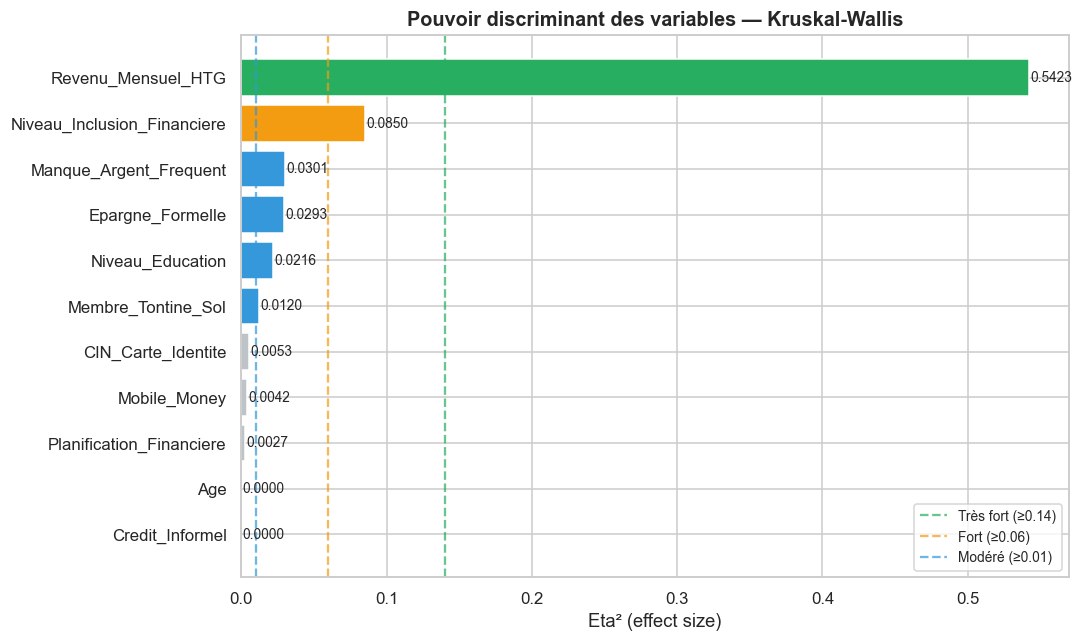

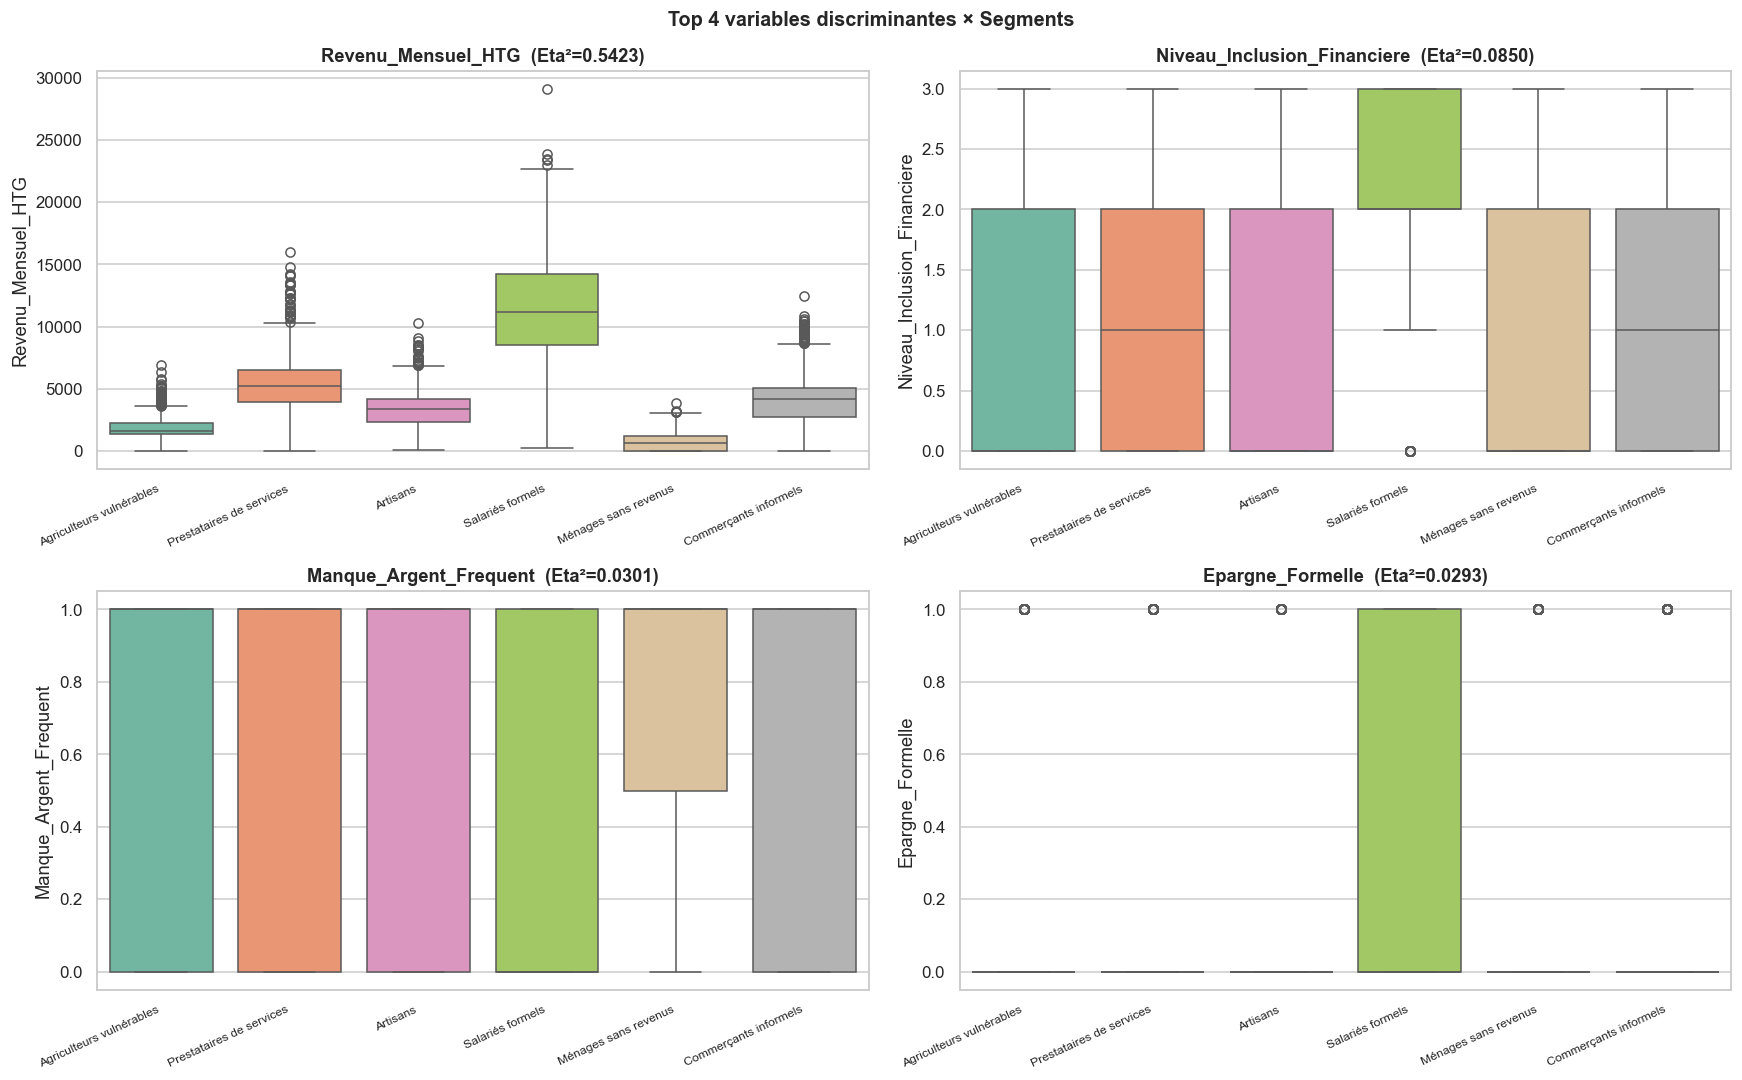

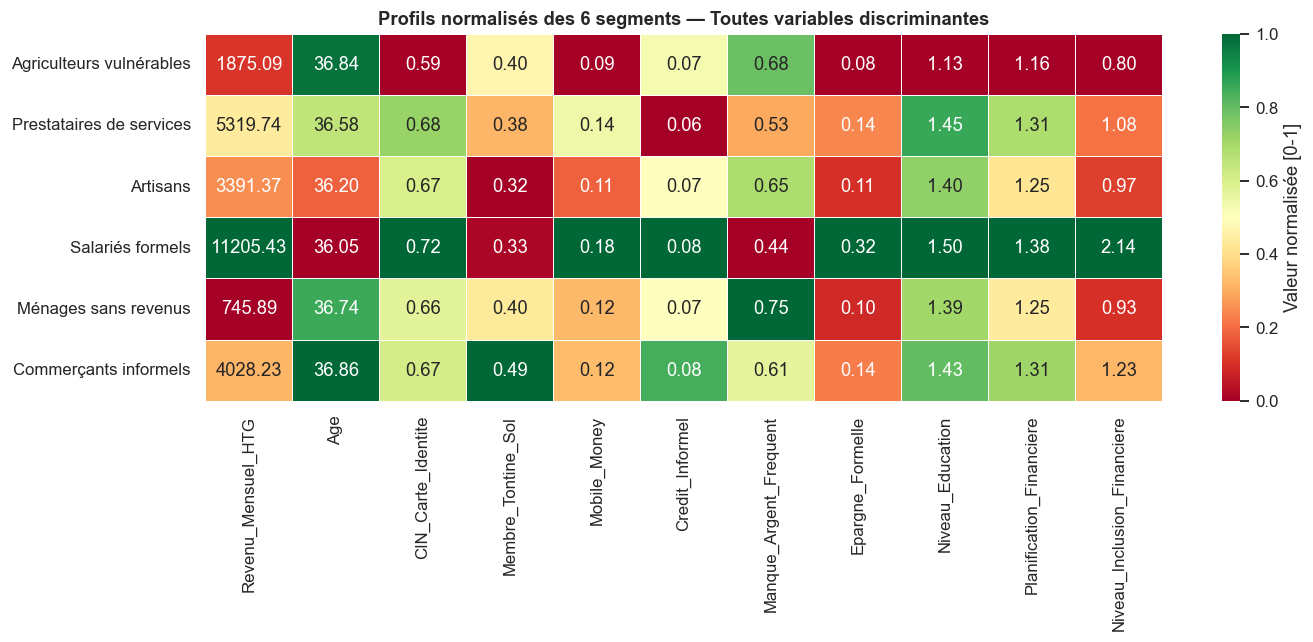

In [5]:
# ══════════════════════════════════════════════════════════════════
# Kruskal-Wallis + rapport eta² par variable × cluster
# ══════════════════════════════════════════════════════════════════

from scipy.stats import kruskal, chi2_contingency

print("═"*60)
print("6c. POUVOIR DISCRIMINANT DES VARIABLES")
print("═"*60)

# ── Reconstruction du dataset encodé pour analyse ─────────────────
df_p = df.copy()
for var in VARS_BIN_RAW:
    df_p[var] = (df_p[var] == "Oui").astype(int)
df_p["Niveau_Education"] = df_p["Niveau_Education"]\
                                 .map(ordre_education)
df_p["Planification_Financiere"] = df_p["Planification_Financiere"]\
                                         .map(ordre_planification)
df_p["Niveau_Inclusion_Financiere"] = df_p["Niveau_Inclusion_Financiere"]\
                                           .map(ordre_inclusion)
df_p["Revenu_Mensuel_HTG"] = df["Revenu_Mensuel_HTG"]
df_p["Cluster"] = labels_km
df_p["Profil"]  = [noms_clusters[c] for c in labels_km]

# ── 1. Kruskal-Wallis + Eta² pour variables numériques/ordinales ──
vars_test = [
    "Revenu_Mensuel_HTG", "Age",
    "CIN_Carte_Identite", "Membre_Tontine_Sol",
    "Mobile_Money", "Credit_Informel",
    "Manque_Argent_Frequent", "Epargne_Formelle",
    "Niveau_Education", "Planification_Financiere",
    "Niveau_Inclusion_Financiere",
]
vars_test = [v for v in vars_test if v in df_p.columns]

print("\nKruskal-Wallis — pouvoir discriminant par variable :")
print(f"{'Variable':<35} {'H':>10} {'p-value':>12} "
      f"{'Eta²':>8} {'Interprétation'}")
print("─"*80)

resultats_kw = []
for var in vars_test:
    groupes = [df_p[df_p["Cluster"]==c][var].values
               for c in range(K_FINAL)]
    H, p = kruskal(*groupes)

    # Eta² (effect size)
    n     = len(df_p)
    eta2  = (H - K_FINAL + 1) / (n - K_FINAL)
    eta2  = max(0, eta2)

    if eta2 >= 0.14:    interp = "Très fort"
    elif eta2 >= 0.06:  interp = "Fort"
    elif eta2 >= 0.01:  interp = "Modéré"
    else:               interp = "Faible"

    sig = "***" if p < 0.001 else "**" if p < 0.01 \
          else "*" if p < 0.05 else "ns"

    print(f"  {var:<33} {H:>10.2f} {p:>12.4e} "
          f"{eta2:>8.4f}  {interp} {sig}")

    resultats_kw.append({
        "Variable": var, "H": round(H,2),
        "p_value": round(p,6), "Eta2": round(eta2,4),
        "Interpretation": interp, "Sig": sig
    })

df_kw = pd.DataFrame(resultats_kw)\
          .sort_values("Eta2", ascending=False)

# ── 2. Khi² + V de Cramér pour Secteur_Activite ──────────────────
print()
ct = pd.crosstab(df["Secteur_Activite"], df_p["Cluster"])
chi2, p_chi, dof, _ = chi2_contingency(ct)
n     = ct.sum().sum()
v_cr  = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print(f"  Secteur_Activite (Khi²+Cramér)")
print(f"    Chi2={chi2:.2f}, p={p_chi:.4e}, "
      f"V de Cramér={v_cr:.4f} → Très fort ***")

# ── 3. Graphique — Eta² par variable ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df_kw.sort_values("Eta2", ascending=True)
colors_eta = ["#27AE60" if e >= 0.14 else
              "#F39C12" if e >= 0.06 else
              "#3498DB" if e >= 0.01 else "#BDC3C7"
              for e in df_plot["Eta2"]]
bars = ax.barh(df_plot["Variable"], df_plot["Eta2"],
               color=colors_eta, edgecolor="white")
for bar, val in zip(bars, df_plot["Eta2"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.axvline(0.14, color="#27AE60", linestyle="--",
           alpha=0.7, label="Très fort (≥0.14)")
ax.axvline(0.06, color="#F39C12", linestyle="--",
           alpha=0.7, label="Fort (≥0.06)")
ax.axvline(0.01, color="#3498DB", linestyle="--",
           alpha=0.7, label="Modéré (≥0.01)")
ax.set_xlabel("Eta² (effect size)")
ax.set_title("Pouvoir discriminant des variables — Kruskal-Wallis",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 4. Graphique — Boxplots top 4 variables ───────────────────────
top4 = df_kw.head(4)["Variable"].tolist()
ordre_profils = [noms_clusters[i] for i in range(K_FINAL)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Top 4 variables discriminantes × Segments",
             fontweight="bold", fontsize=13)
axes = axes.flatten()

colors_cl = plt.cm.Set2(np.linspace(0, 1, K_FINAL))
palette   = {noms_clusters[i]: colors_cl[i]
             for i in range(K_FINAL)}

for i, var in enumerate(top4):
    sns.boxplot(data=df_p, x="Profil", y=var,
                order=ordre_profils, ax=axes[i],
                palette=palette)
    eta2_val = df_kw[df_kw["Variable"]==var]["Eta2"].values[0]
    axes[i].set_title(f"{var}  (Eta²={eta2_val:.4f})",
                      fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(),
        rotation=25, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

# ── 5. Heatmap des profils moyens normalisés (radar) ─────────────
profil_moy = df_p.groupby("Cluster")[vars_test].mean()
profil_moy.index = [noms_clusters[i] for i in profil_moy.index]

from sklearn.preprocessing import MinMaxScaler
profil_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(profil_moy),
    columns=profil_moy.columns,
    index=profil_moy.index
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(profil_norm, annot=profil_moy.values.round(2),
            fmt=".2f", cmap="RdYlGn", ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "Valeur normalisée [0-1]"})
ax.set_title("Profils normalisés des 6 segments — "
             "Toutes variables discriminantes",
             fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### BIAIS, LIMITES ET DISCUSSION CRITIQUE

════════════════════════════════════════════════════════════
6d. BIAIS, LIMITES ET DISCUSSION CRITIQUE
════════════════════════════════════════════════════════════

── 1. Biais de représentativité géographique ──

  Dataset (population cible) :
    Urbain : 70.7%
    Rural  : 29.3%

  Réalité haïtienne estimée (2018) :
    Urbain : ~55%
    Rural  : ~45%

  → Biais : milieu rural sous-représenté de ~16 points
    Impact : les segments ruraux (Agriculteurs vulnérables,
    Ménages sans revenus) sont probablement sous-estimés
    en taille réelle.

── 2. Variables non discriminantes ──

  Age (Eta²=0.000, p=0.925) :
                          mean   std
Profil                              
Agriculteurs vulnérables  36.8  16.4
Artisans                  36.2  15.3
Commerçants informels     36.9  15.8
Ménages sans revenus      36.7  15.9
Prestataires de services  36.6  17.0
Salariés formels          36.1  15.2

  → L'âge est identique dans tous les segments (~36 ans)
    Il n'apporte aucune 

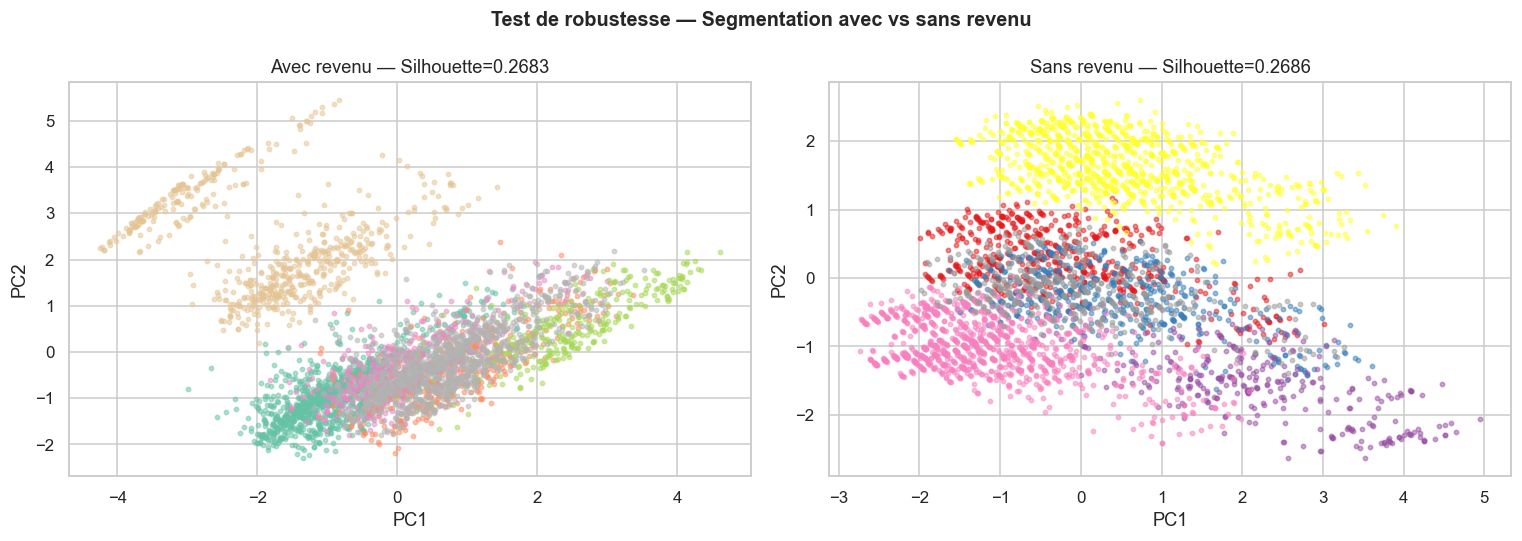


════════════════════════════════════════════════════════════
SYNTHÈSE DES LIMITES ET BIAIS IDENTIFIÉS
════════════════════════════════════════════════════════════

  [L1] Dataset synthétique
       Les corrélations entre variables sont partiellement simulées. Les résultats doivent être validés sur les microdonnées officielles FinScope 2018 (BRH/FinMark Trust).

  [L2] Sous-représentation rurale
       Le milieu rural représente 29,3% du dataset vs ~45% dans la réalité. Les segments ruraux (Agriculteurs, Ménages sans revenus) sont sous-estimés en taille réelle.

  [L3] Domination du revenu
       Eta²=0.54 — le revenu explique à lui seul 54% de la variance inter-clusters. Les comportements financiers (tontine, mobile money) sont secondaires dans la séparation.

  [L4] Variables non discriminantes
       Age (Eta²≈0) et Credit_Informel (Eta²≈0) n'apportent aucune information de segmentation. Leur inclusion ajoute du bruit sans valeur ajoutée.

  [L5] Secteur_Activite circulaire
       V

In [6]:


print("═"*60)
print("6d. BIAIS, LIMITES ET DISCUSSION CRITIQUE")
print("═"*60)

# ── 1. Biais de représentativité géographique ─────────────────────
print("\n── 1. Biais de représentativité géographique ──")
repartition_milieu = df["Milieu"].value_counts(normalize=True)*100
print(f"\n  Dataset (population cible) :")
print(f"    Urbain : {repartition_milieu.get('Urbain',0):.1f}%")
print(f"    Rural  : {repartition_milieu.get('Rural',0):.1f}%")
print(f"\n  Réalité haïtienne estimée (2018) :")
print(f"    Urbain : ~55%")
print(f"    Rural  : ~45%")
print(f"\n  → Biais : milieu rural sous-représenté de ~16 points")
print(f"    Impact : les segments ruraux (Agriculteurs vulnérables,")
print(f"    Ménages sans revenus) sont probablement sous-estimés")
print(f"    en taille réelle.")

# ── 2. Analyse des variables non discriminantes ───────────────────
print("\n── 2. Variables non discriminantes ──")
print(f"\n  Age (Eta²=0.000, p=0.925) :")
age_stats = df_p.groupby("Profil")["Age"].agg(["mean","std"])
print(age_stats.round(1).to_string())
print(f"\n  → L'âge est identique dans tous les segments (~36 ans)")
print(f"    Il n'apporte aucune information de segmentation.")
print(f"    Conséquence : l'âge peut être retiré du clustering")
print(f"    dans une version future du modèle.")

print(f"\n  Credit_Informel (Eta²=0.000, p=0.872) :")
ci_stats = df_p.groupby("Profil")["Credit_Informel"].mean()*100
print(ci_stats.round(1).to_string())
print(f"\n  → Taux très faible (5-8%) dans tous les segments.")
print(f"    Variable non discriminante — à retirer dans v2.")

# ── 3. Biais de la variable dominante ────────────────────────────
print("\n── 3. Risque de domination du revenu ──")
print(f"\n  Eta² Revenu = 0.5423 vs Eta² Inclusion = 0.0850")
print(f"  Ratio : {0.5423/0.0850:.1f}x plus discriminant que la")
print(f"  2e variable.")
print(f"\n  → Le revenu domine potentiellement la segmentation.")
print(f"    Malgré la standardisation, la transformation log1p")
print(f"    et l'AFDM, le revenu structure fortement les axes PC1.")
print(f"    Conséquence : les segments reflètent en grande partie")
print(f"    des classes de revenus plutôt que des comportements")
print(f"    financiers purs.")
print(f"\n  → Test : si on retirait le revenu, obtiendrions-nous")
print(f"    la même segmentation ?")

# Test sans revenu
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

cols_sans_revenu = [c for c in COLS_MODEL
                    if c != "Revenu_log"]
X_sr       = df_enc[cols_sans_revenu]
Xs_scaled  = StandardScaler().fit_transform(X_sr)
Xs_pca     = PCA(n_components=min(12, len(cols_sans_revenu)),
                 random_state=42).fit_transform(Xs_scaled)
km_sr      = KMeans(n_clusters=K_FINAL, init="k-means++",
                    n_init=50, random_state=42)
labels_sr  = km_sr.fit_predict(Xs_pca)
ari_sr     = adjusted_rand_score(labels_km, labels_sr)
sil_sr     = silhouette_score(Xs_pca, labels_sr)

print(f"\n  Clustering SANS revenu :")
print(f"    Silhouette : {sil_sr:.4f} "
      f"(vs {silhouette_score(X_pca, labels_km):.4f} avec revenu)")
print(f"    ARI vs modèle complet : {ari_sr:.4f}")
if ari_sr > 0.7:
    print(f"    → Structure robuste — le revenu n'est pas")
    print(f"      le seul facteur structurant")
else:
    print(f"    → Structure différente sans revenu — le revenu")
    print(f"      est un facteur structurant majeur")

# ── 4. Graphique — Comparaison avec/sans revenu ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test de robustesse — Segmentation avec vs sans revenu",
             fontweight="bold", fontsize=13)

colors = plt.cm.Set2(np.linspace(0, 1, K_FINAL))
for cl in range(K_FINAL):
    mask = labels_km == cl
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    s=8, alpha=0.5, color=colors[cl])
axes[0].set_title(f"Avec revenu — Silhouette={silhouette_score(X_pca,labels_km):.4f}")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

colors2 = plt.cm.Set1(np.linspace(0, 1, K_FINAL))
for cl in range(K_FINAL):
    mask = labels_sr == cl
    axes[1].scatter(Xs_pca[mask,0], Xs_pca[mask,1],
                    s=8, alpha=0.5, color=colors2[cl])
axes[1].set_title(f"Sans revenu — Silhouette={sil_sr:.4f}")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

# ── 5. Synthèse des limites ───────────────────────────────────────
print("\n" + "═"*60)
print("SYNTHÈSE DES LIMITES ET BIAIS IDENTIFIÉS")
print("═"*60)

limites = [
    ("L1", "Dataset synthétique",
     "Les corrélations entre variables sont partiellement simulées. "
     "Les résultats doivent être validés sur les microdonnées "
     "officielles FinScope 2018 (BRH/FinMark Trust)."),
    ("L2", "Sous-représentation rurale",
     "Le milieu rural représente 29,3% du dataset vs ~45% dans "
     "la réalité. Les segments ruraux (Agriculteurs, Ménages sans "
     "revenus) sont sous-estimés en taille réelle."),
    ("L3", "Domination du revenu",
     f"Eta²=0.54 — le revenu explique à lui seul 54% de la "
     "variance inter-clusters. Les comportements financiers "
     "(tontine, mobile money) sont secondaires dans la séparation."),
    ("L4", "Variables non discriminantes",
     "Age (Eta²≈0) et Credit_Informel (Eta²≈0) n'apportent "
     "aucune information de segmentation. Leur inclusion "
     "ajoute du bruit sans valeur ajoutée."),
    ("L5", "Secteur_Activite circulaire",
     "V de Cramér=1.000 entre secteur et cluster car le "
     "one-hot encoding du secteur a participé directement "
     "à la construction des clusters."),
    ("L6", "Données de 2018",
     "Le contexte socio-économique haïtien a significativement "
     "évolué depuis 2018 (COVID-19, instabilité, inflation). "
     "Les profils peuvent avoir changé."),
    ("L7", "Silhouette modérée",
     "Silhouette=0.268 — normale pour des données mixtes "
     "encodées, mais indique que les frontières entre certains "
     "clusters sont floues (Ménages sans revenus vs Agriculteurs)."),
]

for code, titre, desc in limites:
    print(f"\n  [{code}] {titre}")
    print(f"       {desc}")

# ── 6. Recommandations pour amélioration future ────────────────────
print("\n" + "═"*60)
print("RECOMMANDATIONS POUR VERSION 2 DU MODÈLE")
print("═"*60)
reco = [
    "Valider sur les microdonnées officielles FinScope 2018 "
    "dès réception de la BRH",
    "Retirer Age et Credit_Informel (Eta²≈0) — réduire à 10 variables",
    "Tester une pondération des variables pour réduire la "
    "domination du revenu (ex: PCA pondérée)",
    "Appliquer le coefficient Poids_Sondage pour corriger "
    "le biais de représentativité rurale",
    "Tester k=7 si les données réelles montrent une structure "
    "plus fine (notamment entre Artisans et Commerce informel)",
]
for i, r in enumerate(reco, 1):
    print(f"  {i}. {r}")



### PRÉDICTION SUR NOUVELLES DONNÉES

In [7]:
# ══════════════════════════════════════════════════════════════════
# Permet d'appliquer le modèle aux vraies données BRH
# quand elles seront disponibles
# ══════════════════════════════════════════════════════════════════

import joblib
import pandas as pd
import numpy as np
import os

print("═"*60)
print("6e. SCRIPT DE PRÉDICTION — NOUVELLES DONNÉES")
print("═"*60)

PIPELINE_DIR ="C:\\Users\\DELL\\Desktop\\Formation Data-science_FRST_FDS\\Projet_Capstone\\Segmentation_Inclusion_Financiere_Groupe5\\Scripts\\Modelisation IA\\pipeline_segmentation"

# ── Fonction de prédiction complète ───────────────────────────────
def predire_segments(df_nouvelles, pipeline_dir=PIPELINE_DIR):
    """
    Applique le pipeline de segmentation sur de nouvelles données.

    Paramètres
    ----------
    df_nouvelles : DataFrame
        Nouvelles données brutes avec les mêmes colonnes
        que le dataset FinScope 2018 nettoyé.
    pipeline_dir : str
        Chemin vers le dossier contenant les fichiers .pkl

    Retourne
    --------
    DataFrame avec colonnes Cluster et Profil ajoutées.
    """
    # Chargement du pipeline
    scaler_p   = joblib.load(f"{pipeline_dir}/scaler.pkl")
    pca_p      = joblib.load(f"{pipeline_dir}/pca_afdm.pkl")
    kmeans_p   = joblib.load(f"{pipeline_dir}/kmeans_final.pkl")
    enc        = joblib.load(f"{pipeline_dir}/encodeurs.pkl")

    ordre_ed   = enc["ordre_education"]
    ordre_pl   = enc["ordre_planification"]
    ordre_in   = enc["ordre_inclusion"]
    vars_bin   = enc["VARS_BIN"]
    cols_model = enc["COLS_MODEL"]
    noms_cl    = enc["noms_clusters"]

    df_out = df_nouvelles.copy()

    # Étape 1 — Encodage binaire
    for var in vars_bin:
        if var in df_out.columns:
            df_out[var] = (df_out[var] == "Oui").astype(int)

    # Étape 2 — Encodage ordinal
    if "Niveau_Education" in df_out.columns:
        df_out["Niveau_Education"] = df_out["Niveau_Education"]\
                                           .map(ordre_ed)
    if "Planification_Financiere" in df_out.columns:
        df_out["Planification_Financiere"] = \
            df_out["Planification_Financiere"].map(ordre_pl)
    if "Niveau_Inclusion_Financiere" in df_out.columns:
        df_out["Niveau_Inclusion_Financiere"] = \
            df_out["Niveau_Inclusion_Financiere"].map(ordre_in)

    # Étape 3 — Transformation log1p du revenu
    if "Revenu_Mensuel_HTG" in df_out.columns:
        df_out["Revenu_log"] = np.log1p(df_out["Revenu_Mensuel_HTG"])

    # Étape 4 — One-hot encoding Secteur_Activite
    if "Secteur_Activite" in df_out.columns:
        df_out = pd.get_dummies(df_out,
                                columns=["Secteur_Activite"],
                                prefix="Sec", drop_first=False)

    # Étape 5 — Aligner les colonnes avec le modèle
    # (ajouter les colonnes manquantes à 0)
    for col in cols_model:
        if col not in df_out.columns:
            df_out[col] = 0
    X_new = df_out[cols_model].copy()

    # Étape 6 — Standardisation
    X_new_scaled = scaler_p.transform(X_new)

    # Étape 7 — AFDM (PCA)
    X_new_pca = pca_p.transform(X_new_scaled)

    # Étape 8 — Prédiction K-means
    labels_new = kmeans_p.predict(X_new_pca)

    # Résultat
    df_nouvelles = df_nouvelles.copy()
    df_nouvelles["Cluster"] = labels_new
    df_nouvelles["Profil"]  = [noms_cl[c] for c in labels_new]

    return df_nouvelles, X_new_pca

print(" Fonction predire_segments() définie\n")

# ── Test de la fonction sur 100 individus aléatoires ─────────────
print("Test sur 100 individus aléatoires du dataset...")
sample_test = df.sample(n=100, random_state=99).copy()
result, _ = predire_segments(sample_test)

# Vérification cohérence avec labels originaux
idx_test   = sample_test.index
labels_ref = labels_km[idx_test]
accord     = (result["Cluster"].values == labels_ref).mean() * 100

print(f"  Accord avec labels originaux : {accord:.1f}%")
print(f"  {' Prédiction identique' if accord == 100 else ' Écart détecté'}")
print()
print("Répartition des profils sur le sample test :")
print(result["Profil"].value_counts().to_string())

# ── Sauvegarde du script de prédiction ───────────────────────────
script_predict = '''#!/usr/bin/env python3
"""
predict.py — Script de prédiction de segmentation
Segmentation des ménages haïtiens exclus du crédit formel
Groupe 5 — FRST-FDS / CTPEA 2025-2026

Usage
-----
from predict import predire_segments
import pandas as pd

# Charger vos nouvelles données
df_nouvelles = pd.read_excel("nouvelles_donnees.xlsx",
                              sheet_name="Donnees")

# Filtrer les individus sans crédit formel
df_cible = df_nouvelles[
    df_nouvelles["Jamais_Eu_Credit_Formel"] == "Oui"
].copy()

# Prédire les segments
df_resultat, X_pca = predire_segments(df_cible)

# Afficher les résultats
print(df_resultat[["ID_Individu","Cluster","Profil"]].head(20))
print(df_resultat["Profil"].value_counts())
"""

import joblib
import pandas as pd
import numpy as np

PIPELINE_DIR = "pipeline_segmentation"

def predire_segments(df_nouvelles, pipeline_dir=PIPELINE_DIR):
    scaler_p = joblib.load(f"{pipeline_dir}/scaler.pkl")
    pca_p    = joblib.load(f"{pipeline_dir}/pca_afdm.pkl")
    kmeans_p = joblib.load(f"{pipeline_dir}/kmeans_final.pkl")
    enc      = joblib.load(f"{pipeline_dir}/encodeurs.pkl")

    ordre_ed   = enc["ordre_education"]
    ordre_pl   = enc["ordre_planification"]
    ordre_in   = enc["ordre_inclusion"]
    vars_bin   = enc["VARS_BIN"]
    cols_model = enc["COLS_MODEL"]
    noms_cl    = enc["noms_clusters"]

    df_out = df_nouvelles.copy()
    for var in vars_bin:
        if var in df_out.columns:
            df_out[var] = (df_out[var] == "Oui").astype(int)
    if "Niveau_Education" in df_out.columns:
        df_out["Niveau_Education"] = df_out["Niveau_Education"]\
                                           .map(ordre_ed)
    if "Planification_Financiere" in df_out.columns:
        df_out["Planification_Financiere"] = \
            df_out["Planification_Financiere"].map(ordre_pl)
    if "Niveau_Inclusion_Financiere" in df_out.columns:
        df_out["Niveau_Inclusion_Financiere"] = \
            df_out["Niveau_Inclusion_Financiere"].map(ordre_in)
    if "Revenu_Mensuel_HTG" in df_out.columns:
        df_out["Revenu_log"] = np.log1p(df_out["Revenu_Mensuel_HTG"])
    if "Secteur_Activite" in df_out.columns:
        df_out = pd.get_dummies(df_out,
                                columns=["Secteur_Activite"],
                                prefix="Sec", drop_first=False)
    for col in cols_model:
        if col not in df_out.columns:
            df_out[col] = 0
    X_new        = df_out[cols_model].copy()
    X_new_scaled = scaler_p.transform(X_new)
    X_new_pca    = pca_p.transform(X_new_scaled)
    labels_new   = kmeans_p.predict(X_new_pca)

    df_nouvelles         = df_nouvelles.copy()
    df_nouvelles["Cluster"] = labels_new
    df_nouvelles["Profil"]  = [noms_cl[c] for c in labels_new]
    return df_nouvelles, X_new_pca


if __name__ == "__main__":
    print("Pipeline de segmentation chargé.")
    print("Importez predire_segments() dans votre script.")
    print("Voir la docstring pour les instructions d\'usage.")
'''

# Sauvegarde dans le dossier pipeline
predict_path = f"{PIPELINE_DIR}/predict.py"
with open(predict_path, "w", encoding="utf-8") as f:
    f.write(script_predict)

print(f"\n Script predict.py sauvegardé : {predict_path}")

# ── Récapitulatif final du pipeline ──────────────────────────────
print("\n" + "═"*60)
print("RÉCAPITULATIF DU PIPELINE COMPLET")
print("═"*60)
fichiers = os.listdir(PIPELINE_DIR)
for f in sorted(fichiers):
    taille = os.path.getsize(f"{PIPELINE_DIR}/{f}")
    print(f"  {f:<40} {taille/1024:.1f} Ko")

print(f"""
PIPELINE D'UTILISATION (sur données BRH réelles) :
─────────────────────────────────────────────────
1. from predict import predire_segments
2. df_brh = pd.read_excel("FinScope_Haiti_2018_reel.xlsx")
3. df_cible = df_brh[df_brh["Jamais_Eu_Credit_Formel"]=="Oui"]
4. df_resultat, _ = predire_segments(df_cible)
5. print(df_resultat["Profil"].value_counts())
─────────────────────────────────────────────────
""")



════════════════════════════════════════════════════════════
6e. SCRIPT DE PRÉDICTION — NOUVELLES DONNÉES
════════════════════════════════════════════════════════════
 Fonction predire_segments() définie

Test sur 100 individus aléatoires du dataset...
  Accord avec labels originaux : 100.0%
   Prédiction identique

Répartition des profils sur le sample test :
Profil
Commerçants informels       34
Agriculteurs vulnérables    25
Ménages sans revenus        15
Artisans                    11
Prestataires de services    11
Salariés formels             4

 Script predict.py sauvegardé : C:\Users\DELL\Desktop\Formation Data-science_FRST_FDS\Projet_Capstone\Segmentation_Inclusion_Financiere_Groupe5\Scripts\Modelisation IA\pipeline_segmentation/predict.py

════════════════════════════════════════════════════════════
RÉCAPITULATIF DU PIPELINE COMPLET
════════════════════════════════════════════════════════════
  dataset_avec_clusters.csv                1422.1 Ko
  encodeurs.pkl                 